# XKCD Color Survey Analysis

Exploring the main survey dataset and filtering color names

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../mainsurvey.csv")
df.head()

,r,g,b,colorname
0,72,100,175,blue pastel
1,182,226,245,baby blue
2,130,64,234,purple
3,75,49,234,blue
4,76,215,249,blue light


In [3]:
# Dataset overview
print(f"Total responses: {len(df):,}")
# print(f"Unique color names: {df['colorname'].nunique():,}")
print(f"Unique colors (RGB): {df[['r', 'g', 'b']].drop_duplicates().shape[0]:,}")

Total responses: 3,007,377
Unique colors (RGB): 2,752,868


## Filters

## CCDF of Color Name Frequencies

=== Mined data ===


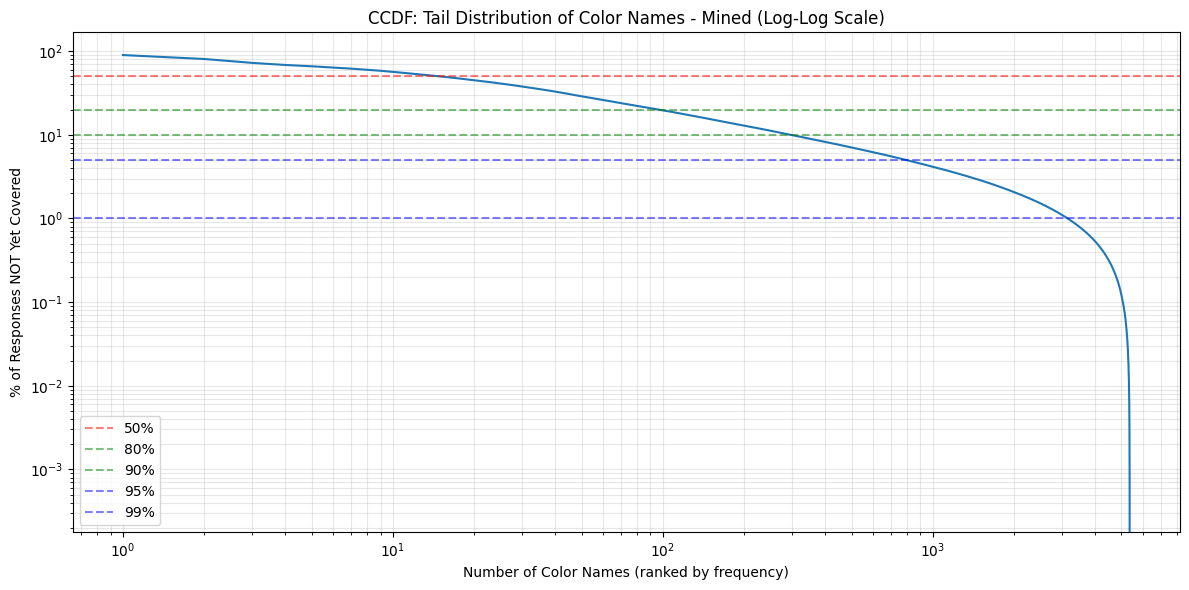

Color names needed for coverage - Mined:


,Coverage,Color Names,Entries
0,50%,14,1474550
1,80%,96,2403593
2,90%,298,2706361
3,95%,797,2856977
4,99%,3160,2977293
5,100%,5363,3007377


In [4]:
import matplotlib.pyplot as plt

def plot_ccdf(data, title_suffix=""):
    """Plot CCDF of color name frequencies and print coverage statistics.
    
    Args:
        data: DataFrame with 'colorname' column
        title_suffix: Optional suffix to add to the plot title
    """
    # Get color name counts and sort
    counts = data['colorname'].value_counts().sort_values(ascending=False)
    
    # Calculate CCDF (complementary CDF)
    cumsum = counts.cumsum()
    ccdf = (1 - cumsum / cumsum.iloc[-1]) * 100
    
    # Plot on log-log scale
    plt.figure(figsize=(12, 6))
    plt.loglog(range(1, len(ccdf)+1), ccdf.values)
    plt.xlabel('Number of Color Names (ranked by frequency)')
    plt.ylabel('% of Responses NOT Yet Covered')
    plt.title(f'CCDF: Tail Distribution of Color Names{title_suffix} (Log-Log Scale)')
    plt.grid(True, alpha=0.3, which='both')
    plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='50%')
    plt.axhline(y=20, color='g', linestyle='--', alpha=0.5, label='80%')
    plt.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='90%')
    plt.axhline(y=5, color='b', linestyle='--', alpha=0.5, label='95%')
    plt.axhline(y=1, color='b', linestyle='--', alpha=0.5, label='99%')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Create coverage statistics table
    coverage_data = []
    total_responses = len(data)
    
    for pct in [50, 80, 90, 95, 99]:
        n_colors = (ccdf >= (100 - pct)).sum()
        entries = int(cumsum.iloc[n_colors - 1]) if n_colors > 0 else 0
        coverage_data.append({
            'Coverage': f'{pct}%',
            'Color Names': n_colors,
            'Entries': entries
        })
    
    # Add 100% coverage
    coverage_data.append({
        'Coverage': '100%',
        'Color Names': len(ccdf),
        'Entries': total_responses
    })
    
    coverage_df = pd.DataFrame(coverage_data)
    
    print(f"Color names needed for coverage{title_suffix}:")
    display(coverage_df)


# Run for both dataframes
print("=== Mined data ===")
plot_ccdf(df, " - Mined")

## Export Data to CSV

In [ ]:
# Distribution of rows for the top N most frequent color names
top_n = 20  # change as needed

top_colors_dist = (
    df["colorname"]
    .value_counts()
    .head(top_n)
    .rename_axis("colorname")
    .reset_index(name="rows")
)

print(f"Top {top_n} colors by number of rows:")
display(top_colors_dist)

# Optional plot
ax = top_colors_dist.sort_values("rows").plot(
    kind="barh",
    x="colorname",
    y="rows",
    figsize=(10, 6),
    legend=False,
    title=f"Top {top_n} colors by row count"
)
ax.set_xlabel("Number of rows")
ax.set_ylabel("Color name")
plt.tight_layout()
plt.show()

NameError: name 'df_filtered' is not defined